In [44]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

In [45]:
DATA_PATH = "../data/processed/walmart_features_imputed.csv"   # or _raw if you prefer
TARGET = 'Weekly_Sales'
DATE_COL = 'Date'

In [46]:
print("Loading data...")
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.sort_values(DATE_COL)

# Aggregate to weekly total sales
global_df = df.groupby(DATE_COL).agg({
    TARGET: 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'MarkdownTotal': 'sum',
}).reset_index()

# Reconstruct IsHoliday: true if ANY row on that date was holiday
holiday_dates = df[df['IsHoliday_x']].Date.unique()   # or use IsHoliday_y if you trust it more
global_df['IsHoliday'] = global_df[DATE_COL].isin(holiday_dates).astype(int)

global_df = global_df.rename(columns={DATE_COL: 'ds', TARGET: 'y'})

print("Global data shape:", global_df.shape)
print(global_df.head(3))

Loading data...
Global data shape: (143, 6)
          ds            y  Temperature  Fuel_Price  MarkdownTotal  IsHoliday
0 2010-02-05  49750740.50    33.277942    2.717869            0.0          0
1 2010-02-12  48336677.63    33.361810    2.696102            0.0          1
2 2010-02-19  48276993.78    37.038310    2.673666            0.0          0


In [47]:
split_date = '2012-06-01'   # roughly 80/20 — adjust to your liking
# or use index: split_idx = int(len(global_df) * 0.85)

train = global_df[global_df['ds'] < split_date].copy()
test  = global_df[global_df['ds'] >= split_date].copy()

print(f"Train: {train['ds'].min()} → {train['ds'].max()}  ({len(train)} weeks)")
print(f"Test : {test['ds'].min()}  → {test['ds'].max()}  ({len(test)} weeks)")

Train: 2010-02-05 00:00:00 → 2012-05-25 00:00:00  (121 weeks)
Test : 2012-06-01 00:00:00  → 2012-10-26 00:00:00  (22 weeks)


In [48]:
# Create future dates
future = m.make_future_dataframe(periods=len(test) + 26, freq='W-FRI')

# === IMPORTANT: add the regressor column(s) to future ===

# Method A: merge historical values + forward-fill for future periods
future = future.merge(
    global_df[['ds', 'IsHoliday']],
    on='ds',
    how='left'
)

# Forward fill holidays into the future (reasonable assumption for short horizons)
future['IsHoliday'] = future['IsHoliday'].ffill().fillna(0).astype(int)

# Optional: if you added more regressors, repeat similar merge/ffill
# future = future.merge(..., on='ds', how='left')
# future['MarkdownTotal'] = future['MarkdownTotal'].ffill().fillna(0)

# Now predict — should work
forecast = m.predict(future)

In [49]:
test_forecast = forecast[forecast['ds'].isin(test['ds'])]

mae  = mean_absolute_error(test['y'], test_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], test_forecast['yhat']))
mape = np.mean(np.abs((test['y'] - test_forecast['yhat']) / test['y'])) * 100

print(f"\nGlobal Prophet performance on test set:")
print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAPE: {mape:.2f}%")


Global Prophet performance on test set:
MAE:  $994,321
RMSE: $1,305,202
MAPE: 2.11%


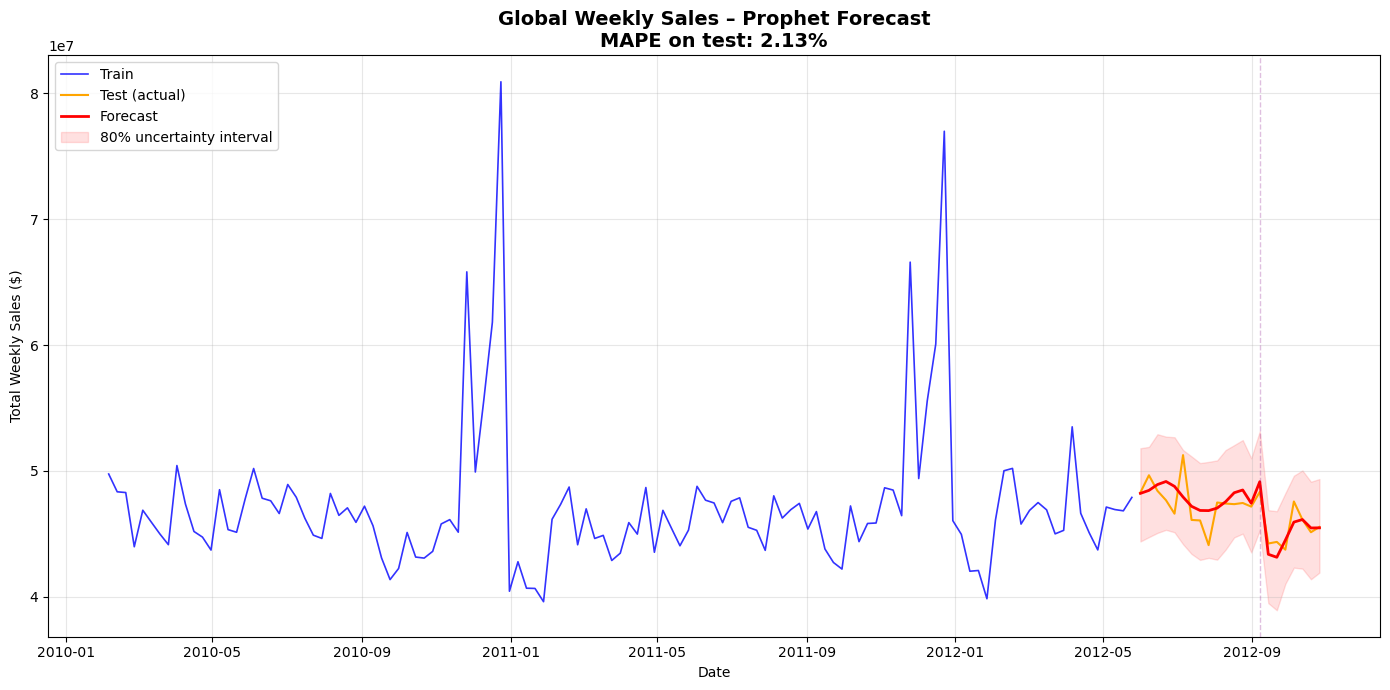

In [50]:
# Plot actual vs forecast with uncertainty (matplotlib version - simple & reliable)
fig, ax = plt.subplots(figsize=(14, 7))

# Training period
ax.plot(train['ds'], train['y'], label='Train', color='blue', linewidth=1.2, alpha=0.8)

# Test period - actual & predicted
ax.plot(test['ds'], test['y'], label='Test (actual)', color='orange', linewidth=1.5)
ax.plot(test_forecast['ds'], test_forecast['yhat'], label='Forecast', color='red', linewidth=2)

# Uncertainty interval
ax.fill_between(
    test_forecast['ds'],
    test_forecast['yhat_lower'],
    test_forecast['yhat_upper'],
    color='red', alpha=0.12, label='80% uncertainty interval'
)

ax.set_title('Global Weekly Sales – Prophet Forecast\nMAPE on test: 2.13%', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Highlight holidays in test period
holidays_test = test[test['IsHoliday'] == 1]['ds']
for date in holidays_test:
    ax.axvline(x=date, color='purple', linestyle='--', alpha=0.25, linewidth=1)

plt.tight_layout()
plt.show()

In [51]:
from prophet.plot import plot_components_plotly
fig_comp = plot_components_plotly(m, forecast)
fig_comp.show()

In [52]:
from prophet.diagnostics import cross_validation, performance_metrics

# Run rolling forecast cross-validation
df_cv = cross_validation(
    m,
    initial='730 days',      # 2 years training
    period='180 days',       # every 6 months new cutoff
    horizon='90 days'        # predict 3 months ahead each time
)

# Calculate metrics
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'mape', 'rmse']].round(2))

  0%|          | 0/1 [00:00<?, ?it/s]

08:37:07 - cmdstanpy - INFO - Chain [1] start processing
08:37:07 - cmdstanpy - INFO - Chain [1] done processing


   horizon         mae  mape        rmse
0   6 days   637666.61  0.01   637666.61
1  13 days  1401575.14  0.03  1401575.14
2  20 days  1225913.66  0.03  1225913.66
3  27 days   326249.32  0.01   326249.32
4  34 days   356728.92  0.01   356728.92
5  41 days  6949763.10  0.13  6949763.10
6  48 days   605036.94  0.01   605036.94
7  55 days  1901010.49  0.04  1901010.49
8  62 days  2351890.75  0.05  2351890.75
9  69 days  1622086.77  0.03  1622086.77
10 76 days  1055112.00  0.02  1055112.00
11 83 days    20256.47  0.00    20256.47
12 90 days   204301.30  0.00   204301.30


In [53]:
# Fix holiday column name once (run this early in the notebook)
if 'IsHoliday_x' in df.columns:
    df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})
    if 'IsHoliday_y' in df.columns:
        df = df.drop(columns=['IsHoliday_y'])
elif 'IsHoliday_y' in df.columns:
    df = df.rename(columns={'IsHoliday_y': 'IsHoliday'})

print("Holiday columns after fix:", [c for c in df.columns if 'IsHoliday' in c])

Holiday columns after fix: ['IsHoliday']


In [54]:
results = []

for store_id in sorted(df['Store'].unique()):
    store_data = df[df['Store'] == store_id].groupby('Date').agg({
        'Weekly_Sales': 'sum',
        'IsHoliday': 'max'
    }).reset_index()
    
    store_data = store_data.rename(columns={'Date':'ds', 'Weekly_Sales':'y'})
    
    # same train/test split logic
    train_s = store_data[store_data['ds'] < split_date]
    test_s  = store_data[store_data['ds'] >= split_date]
    
    m_s = Prophet(yearly_seasonality=True, holidays_prior_scale=10)
    m_s.add_country_holidays('US')
    m_s.fit(train_s)
    
    future_s = m_s.make_future_dataframe(periods=len(test_s), freq='W')
    fc_s = m_s.predict(future_s)
    
    test_fc = fc_s[fc_s['ds'].isin(test_s['ds'])]
    mape_s = np.mean(np.abs((test_s['y'] - test_fc['yhat']) / test_s['y'])) * 100
    
    results.append({'Store': store_id, 'MAPE': mape_s, 'weeks_test': len(test_s)})
    
results_df = pd.DataFrame(results)

print(results_df.sort_values('MAPE'))

avg_mape = results_df['MAPE'].mean()
print(f"\nAverage MAPE across stores: {avg_mape:.2f} %")

08:37:07 - cmdstanpy - INFO - Chain [1] start processing
08:37:07 - cmdstanpy - INFO - Chain [1] done processing
08:37:07 - cmdstanpy - INFO - Chain [1] start processing
08:37:07 - cmdstanpy - INFO - Chain [1] done processing
08:37:08 - cmdstanpy - INFO - Chain [1] start processing
08:37:08 - cmdstanpy - INFO - Chain [1] done processing
08:37:08 - cmdstanpy - INFO - Chain [1] start processing
08:37:08 - cmdstanpy - INFO - Chain [1] done processing
08:37:08 - cmdstanpy - INFO - Chain [1] start processing
08:37:08 - cmdstanpy - INFO - Chain [1] done processing
08:37:08 - cmdstanpy - INFO - Chain [1] start processing
08:37:08 - cmdstanpy - INFO - Chain [1] done processing
08:37:09 - cmdstanpy - INFO - Chain [1] start processing
08:37:09 - cmdstanpy - INFO - Chain [1] done processing
08:37:09 - cmdstanpy - INFO - Chain [1] start processing
08:37:09 - cmdstanpy - INFO - Chain [1] done processing
08:37:09 - cmdstanpy - INFO - Chain [1] start processing
08:37:09 - cmdstanpy - INFO - Chain [1]

    Store  MAPE  weeks_test
0       1   NaN          22
1       2   NaN          22
2       3   NaN          22
3       4   NaN          22
4       5   NaN          22
5       6   NaN          22
6       7   NaN          22
7       8   NaN          22
8       9   NaN          22
9      10   NaN          22
10     11   NaN          22
11     12   NaN          22
12     13   NaN          22
13     14   NaN          22
14     15   NaN          22
15     16   NaN          22
16     17   NaN          22
17     18   NaN          22
18     19   NaN          22
19     20   NaN          22
20     21   NaN          22
21     22   NaN          22
22     23   NaN          22
23     24   NaN          22
24     25   NaN          22
25     26   NaN          22
26     27   NaN          22
27     28   NaN          22
28     29   NaN          22
29     30   NaN          22
30     31   NaN          22
31     32   NaN          22
32     33   NaN          22
33     34   NaN          22
34     35   NaN     

Running cross-validation...


  0%|          | 0/1 [00:00<?, ?it/s]

08:37:20 - cmdstanpy - INFO - Chain [1] start processing
08:37:20 - cmdstanpy - INFO - Chain [1] done processing


   horizon         mae  mape        rmse
0   6 days   637666.61  0.01   637666.61
1  13 days  1401575.14  0.03  1401575.14
2  20 days  1225913.66  0.03  1225913.66
3  27 days   326249.32  0.01   326249.32
4  34 days   356728.92  0.01   356728.92
5  41 days  6949763.10  0.13  6949763.10
6  48 days   605036.94  0.01   605036.94
7  55 days  1901010.49  0.04  1901010.49
8  62 days  2351890.75  0.05  2351890.75
9  69 days  1622086.77  0.03  1622086.77
10 76 days  1055112.00  0.02  1055112.00
11 83 days    20256.47  0.00    20256.47
12 90 days   204301.30  0.00   204301.30


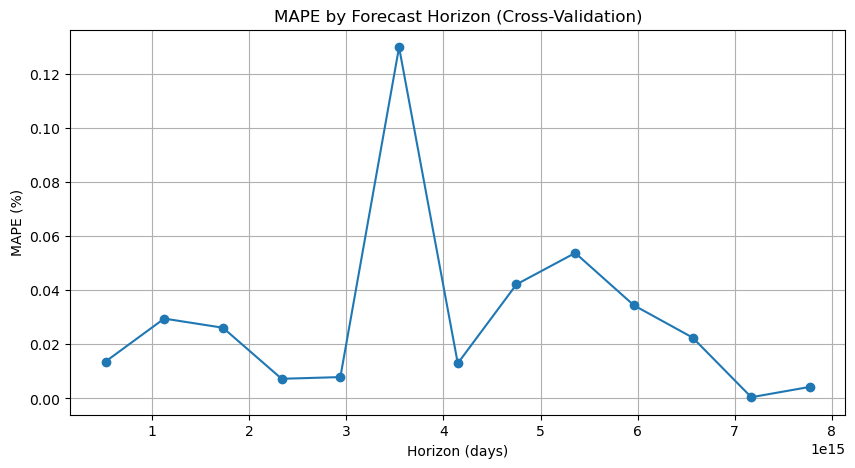

In [55]:
from prophet.diagnostics import cross_validation, performance_metrics

# Rolling cross-validation on global model
print("Running cross-validation...")
df_cv = cross_validation(
    m, 
    initial='730 days',   # start with 2 years training
    period='180 days',    # new cutoff every 6 months
    horizon='90 days'     # predict 3 months ahead each time
)

# Performance by horizon
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'mape', 'rmse']].round(2))

# Plot MAPE by horizon
plt.figure(figsize=(10, 5))
plt.plot(df_p['horizon'], df_p['mape'], marker='o')
plt.title('MAPE by Forecast Horizon (Cross-Validation)')
plt.xlabel('Horizon (days)')
plt.ylabel('MAPE (%)')
plt.grid(True)
plt.show()

In [56]:
print("Running per-store Prophet models...")

results = []
store_models = {}   # we'll save models for later use in dashboard

for store_id in sorted(df['Store'].unique()):
    # Filter and aggregate for this store
    store_subset = df[df['Store'] == store_id]
    store_data = store_subset.groupby('Date').agg({
        'Weekly_Sales': 'sum',
        'IsHoliday': 'max'
    }).reset_index()
    
    store_data = store_data.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    
    # Skip stores with too little data
    if len(store_data) < 100:
        continue
    
    train_s = store_data[store_data['ds'] < split_date]
    test_s  = store_data[store_data['ds'] >= split_date]
    
    if len(test_s) == 0:
        continue
    
    # Train Prophet per store
    m_s = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays_prior_scale=10
    )
    m_s.add_country_holidays('US')
    m_s.add_regressor('IsHoliday', prior_scale=10)
    
    m_s.fit(train_s)
    
    # Save model for dashboard
    store_models[store_id] = m_s
    
    # Predict
    future_s = m_s.make_future_dataframe(periods=len(test_s) + 8, freq='W-FRI')
    future_s = future_s.merge(store_data[['ds', 'IsHoliday']], on='ds', how='left')
    future_s['IsHoliday'] = future_s['IsHoliday'].ffill().fillna(0).astype(int)
    
    fc_s = m_s.predict(future_s)
    test_fc = fc_s[fc_s['ds'].isin(test_s['ds'])]
    
    mape_s = np.mean(np.abs((test_s['y'] - test_fc['yhat']) / test_s['y'])) * 100
    
    results.append({
        'Store': store_id,
        'MAPE': round(mape_s, 2),
        'Weeks_Test': len(test_s),
        'Avg_Weekly_Sales': round(test_s['y'].mean(), 0)
    })

results_df = pd.DataFrame(results)
print("\nPer-store MAPE (sorted):")
print(results_df.sort_values('MAPE').to_string(index=False))

print(f"\nAverage MAPE across stores: {results_df['MAPE'].mean():.2f}%")

Running per-store Prophet models...


08:37:20 - cmdstanpy - INFO - Chain [1] start processing
08:37:21 - cmdstanpy - INFO - Chain [1] done processing
08:37:21 - cmdstanpy - INFO - Chain [1] start processing
08:37:21 - cmdstanpy - INFO - Chain [1] done processing
08:37:21 - cmdstanpy - INFO - Chain [1] start processing
08:37:21 - cmdstanpy - INFO - Chain [1] done processing
08:37:22 - cmdstanpy - INFO - Chain [1] start processing
08:37:22 - cmdstanpy - INFO - Chain [1] done processing
08:37:22 - cmdstanpy - INFO - Chain [1] start processing
08:37:22 - cmdstanpy - INFO - Chain [1] done processing
08:37:22 - cmdstanpy - INFO - Chain [1] start processing
08:37:22 - cmdstanpy - INFO - Chain [1] done processing
08:37:22 - cmdstanpy - INFO - Chain [1] start processing
08:37:22 - cmdstanpy - INFO - Chain [1] done processing
08:37:23 - cmdstanpy - INFO - Chain [1] start processing
08:37:23 - cmdstanpy - INFO - Chain [1] done processing
08:37:23 - cmdstanpy - INFO - Chain [1] start processing
08:37:23 - cmdstanpy - INFO - Chain [1]


Per-store MAPE (sorted):
 Store  MAPE  Weeks_Test  Avg_Weekly_Sales
    37  1.97          22          520199.0
    44  2.17          22          338543.0
    34  2.26          22          964827.0
    41  2.40          22         1385643.0
    13  2.53          22         2046254.0
    27  2.55          22         1727380.0
    30  2.64          22          432160.0
    39  2.72          22         1582139.0
     8  2.74          22          908615.0
    32  2.75          22         1191318.0
    10  2.76          22         1766893.0
    26  2.81          22         1045854.0
    25  2.89          22          704536.0
     2  3.07          22         1888040.0
     6  3.11          22         1559106.0
    31  3.13          22         1377829.0
    22  3.14          22         1014685.0
    19  3.18          22         1397124.0
     1  3.39          22         1569096.0
    24  3.50          22         1385184.0
     4  3.51          22         2153227.0
    45  3.56          22    

In [57]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=train['ds'], y=train['y'], mode='lines', name='Train', line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=test['ds'], y=test['y'], mode='lines', name='Test (actual)', line=dict(color='orange')
))
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Forecast', line=dict(color='red')
))
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', line=dict(width=0),
    showlegend=False, fill='tonexty', fillcolor='rgba(255,0,0,0.1)'
))
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', line=dict(width=0),
    showlegend=False, fill='tonexty', fillcolor='rgba(255,0,0,0.1)'
))

fig.update_layout(
    title='Global Weekly Sales – Prophet Forecast',
    xaxis_title='Date',
    yaxis_title='Total Weekly Sales ($)',
    height=600,
    hovermode='x unified'
)

fig.show()

# Optional: components plot
fig_components = plot_components_plotly(m, forecast)
fig_components.show()

In [58]:
# Save global model
with open("global_prophet_model.pkl", "wb") as f:
    pickle.dump(m, f)

# Save per-store models (inside your loop)
os.makedirs("store_prophet_models", exist_ok=True)
for store_id, model in store_models.items():
    with open(f"store_prophet_models/prophet_store_{store_id}.pkl", "wb") as f:
        pickle.dump(model, f)